## Data Analyzing 03

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### Part 4:

#### 1. Creating the tables that will be needed:

**Table One: orders and customers**

In [2]:
orders_df =pd.read_csv('../Data_Cleaning/olist_orders_dataset_cleaned.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at' ,'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])

In [3]:
customers_df = pd.read_csv('../Data_Cleaning/olist_customers_dataset_cleaned.csv')

In [4]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [5]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'state_name'],
      dtype='object')

In [6]:
orders_customers_df = pd.merge(orders_df,customers_df, left_on='customer_id', right_on='customer_id', how='left')

In [7]:
orders_customers_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
state_name                               object
dtype: object

In [8]:
orders_customers_df['delivery_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_purchase_timestamp']).dt.days

In [9]:
orders_customers_df['carrier_delivery_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_delivered_carrier_date']).dt.days

In [10]:
orders_customers_df['delay_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_estimated_delivery_date']).dt.days

In [11]:
orders_customers_df['is_late'] = orders_customers_df['delay_days'] > 0

**Table Two:**

In [12]:
orders_items_df = pd.read_csv('../Data_Cleaning/olist_order_items_dataset_cleaned.csv')

In [13]:
sellers_df = pd.read_csv('../Data_Cleaning/olist_sellers_dataset_cleaned.csv')

In [14]:
orders_items_df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [15]:
sellers_df.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name'],
      dtype='object')

- this table will be the combination of 3 tables:

In [16]:
items_order_df = pd.merge(orders_items_df, orders_customers_df, left_on='order_id', right_on = 'order_id', how='left' )

In [17]:
full_info_df = pd.merge(items_order_df, sellers_df, left_on='seller_id', right_on = 'seller_id', how= 'left')

In [18]:
full_info_df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name'],
      dtype='object')

In [19]:
full_info_df = full_info_df.drop(columns=['Unnamed: 0'])

**Table Three:**

In [20]:
geolocation_df = pd.read_csv('../Data_Cleaning/olist_geolocation_dataset_cleaned.csv')

In [21]:
geolocation_df.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state', 'state_name'],
      dtype='object')

-  we will group by zip code so to make it easier we'll group the df by zipcode as the lat and long for all duplicated zip codes slightly different we will take the mean: 

In [22]:
geo_grouped_df =  geolocation_df.groupby('geolocation_zip_code_prefix', as_index= False)[['geolocation_lat', 'geolocation_lng']].mean()

In [23]:
geo_customers = geo_grouped_df.rename(columns= {'geolocation_zip_code_prefix' : 'customer_zip_code_prefix', 'geolocation_lat' : 'customer_lat', 'geolocation_lng' : 'customer_lng'})

In [24]:
geo_sellers = geo_grouped_df.rename(columns= {'geolocation_zip_code_prefix' : 'seller_zip_code_prefix', 'geolocation_lat' : 'seller_lat', 'geolocation_lng' : 'seller_lng'})

In [25]:
#we will first merge the customers and align it with the full info table we created before
full_geo_df = pd.merge(full_info_df, geo_customers, left_on='customer_zip_code_prefix', right_on='customer_zip_code_prefix', how='left')

In [26]:
#them also merge the sellers:
full_geo_df = pd.merge(full_geo_df, geo_sellers, left_on='seller_zip_code_prefix', right_on='seller_zip_code_prefix', how='left')

In [27]:
full_geo_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,delay_days,is_late,seller_zip_code_prefix,seller_city,seller_state,seller_state_name,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,-9.0,False,27277,volta redonda,SP,Sao Paulo,-21.763186,-41.310265,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,-3.0,False,3471,sao paulo,SP,Sao Paulo,-20.222506,-50.898951,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,-14.0,False,37564,borda da mata,MG,Minas Gerais,-19.869998,-44.593059,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,-6.0,False,14403,franca,SP,Sao Paulo,-23.105968,-46.590277,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,-16.0,False,87900,loanda,PR,Parana,-23.243402,-46.827614,-22.929583,-53.135750


- we have a lot of NOT needed columns so we'll keep the ones we want only

In [28]:
full_geo_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng'],
      dtype='object')

In [29]:
full_geo_df = full_geo_df.drop(columns=['product_id', 'shipping_limit_date', 'order_approved_at', 'customer_unique_id',  'customer_zip_code_prefix', 'seller_zip_code_prefix'])

In [30]:
full_geo_df = full_geo_df.rename(columns= {'state_name': 'customer_state_name'})

In [31]:
full_geo_df.head()

,order_id,order_item_id,seller_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,...,carrier_delivery_days,delay_days,is_late,seller_city,seller_state,seller_state_name,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-19 18:34:16,2017-09-20 23:43:48,...,1.0,-9.0,False,volta redonda,SP,Sao Paulo,-21.763186,-41.310265,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-04 14:35:00,2017-05-12 16:04:24,...,8.0,-3.0,False,sao paulo,SP,Sao Paulo,-20.222506,-50.898951,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-16 12:36:48,2018-01-22 13:19:16,...,6.0,-14.0,False,borda da mata,MG,Minas Gerais,-19.869998,-44.593059,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-10 13:28:00,2018-08-14 13:32:39,...,4.0,-6.0,False,franca,SP,Sao Paulo,-23.105968,-46.590277,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-16 09:46:09,2017-03-01 16:42:31,...,13.0,-16.0,False,loanda,PR,Parana,-23.243402,-46.827614,-22.929583,-53.135750


#### 2. Answering the Questions:

##### 1. Which states have customers but no sellers?

In [32]:
# finde the states that have sellers: 
sellers_states = sellers_df['seller_state'].unique()

In [33]:
sellers_states

array(['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN',
       'MT', 'CE', 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM',
       'PA'], dtype=object)

In [34]:
#the states that has customers:
customers_states = pd.Series(customers_df['customer_state'].unique())

In [35]:
#now check states that HAVE sellers and states the does NOT HAVE
has_sellers = customers_states.isin(sellers_states)
has_no_sellers = has_sellers == False

In [36]:
no_seller_states = customers_states[has_no_sellers] 

In [37]:
#to make sure we're checking only in brazil
no_seller_table = pd.DataFrame({
    'State': no_seller_states[
        no_seller_states != 'international'
    ].values
})
print(f"Number of states with customers but no sellers: {len(no_seller_table)}")
no_seller_table

Number of states with customers but no sellers: 4


,State
0,AP
1,AL
2,TO
3,RR


##### 2. How is the shipping company performing there? Are deliveries to these states without sellers delayed or on time?

In [38]:
delivered_orders = orders_customers_df[orders_customers_df['order_status'] == 'delivered'].copy()

In [39]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_name,delivery_days,carrier_delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Sao Paulo,8.0,6.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Bahia,13.0,12.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Goias,9.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Rio Grande do Norte,13.0,9.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Sao Paulo,2.0,1.0,-10.0,False


In [40]:
no_seller_orders = delivered_orders[delivered_orders['customer_state'].isin(no_seller_states)]

In [41]:
no_seller_state_summary = no_seller_orders.groupby('customer_state')[['delivery_days', 'carrier_delivery_days', 'delay_days']].mean()

In [42]:
no_seller_state_summary['late_%'] = no_seller_orders.groupby('customer_state')['is_late'].mean() * 100

In [43]:
late_only = no_seller_orders[no_seller_orders['is_late'] == True]

In [44]:
# because here we only need the internal shippings 
no_seller_state_summary = no_seller_state_summary.drop('international') 

In [45]:
national = delivered_orders[['delivery_days', 'carrier_delivery_days', 'delay_days']].mean()
national['late_%'] = delivered_orders['is_late'].mean() * 100
no_seller_state_summary.loc['All states'] = national

In [46]:
chart01_df = no_seller_state_summary[['delivery_days', 'carrier_delivery_days', 'delay_days']].copy()

In [163]:
chart01_df = chart01_df.rename(columns={'delivery_days': 'Total delivery time', 'carrier_delivery_days': 'Carrier delivery time', 'delay_days': 'Days vs. promised date (below 0 = early)'})

In [164]:
late_counts = late_only.groupby('customer_state').size()
total_counts = no_seller_orders['customer_state'].value_counts()

In [165]:
labels = []
for state in no_seller_state_summary.index:
    late = round(no_seller_state_summary.loc[state, 'late_%'], 1)
    if state == 'All states':
        labels.append(f'{state}\n{late}% late')
    else:
        labels.append(f'{state}\n{late}% late\n({late_counts[state]} of {total_counts[state]} orders)')

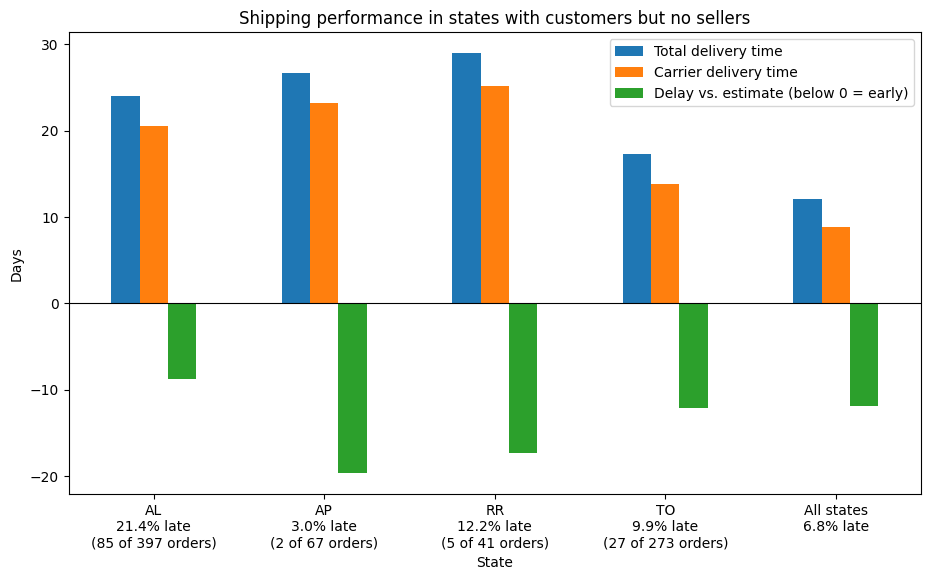

In [168]:
ax = chart01_df.plot(kind='bar', figsize=(11, 6))
ax.set_xticklabels(labels, rotation=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Shipping performance in states with customers but no sellers')
plt.xlabel('State')
plt.ylabel('Days')
plt.show()

##### 3. How do in-state vs. out-of-state deliveries compare in terms of timeliness and cost?

In [187]:
#since we need to compare the in state and out of state we need to have classification
full_geo_df['delivery_type'] = np.where(full_geo_df['seller_state'] == full_geo_df['customer_state'], 'In state', 'Out of state')

In [188]:
delivered_df = full_geo_df[full_geo_df['order_status'] == 'delivered'].copy()

In [189]:
delivered_df = delivered_df[delivered_df['customer_state'] != 'international']

In [190]:
delivered_df['order_id'].duplicated().sum()

np.int64(13665)

In [191]:
per_order_df = (delivered_df.groupby('order_id').agg(
    delivery_type = ('delivery_type', 'first'),
    customer_state = ('customer_state', 'first'),
    seller_state = ('seller_state', 'first'),
    delivery_days = ('delivery_days', 'first'),
    carrier_delivery_days = ('carrier_delivery_days', 'first'), 
    delay_days = ('delay_days', 'first'), 
    is_late = ('is_late', 'first'),
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum')  
).reset_index() )
per_order_df['freight_ratio'] = per_order_df['freight_value'] / per_order_df['price']

In [192]:
in_and_out_state_summary = (
    per_order_df.groupby('delivery_type').agg(
        avg_delivery_days = ('delivery_days', 'mean'), 
        avg_delay_days = ('delay_days', 'mean'),
        percntage_late_days = ('is_late', 'mean'),
        median_freight=('freight_value','median'),
        avg_freight_ratio=('freight_ratio','mean'),
        avg_carrier_days=('carrier_delivery_days','mean'),
        avg_freight = ('freight_value', 'mean')
    )
)
in_and_out_state_summary['percntage_late_days'] *= 100 
in_and_out_state_summary

,avg_delivery_days,avg_delay_days,percntage_late_days,median_freight,avg_freight_ratio,avg_carrier_days,avg_freight
delivery_type,,,,,,,
In state,7.486948,-10.325075,4.51028,12.69,0.238043,4.357877,15.447713
Out of state,14.692326,-12.733179,8.05027,19.04,0.347945,11.420244,26.901475


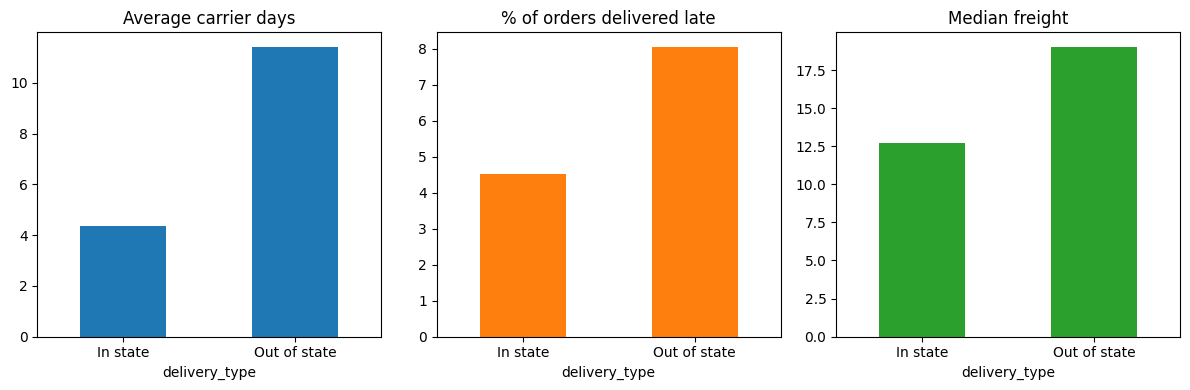

In [195]:
cols = ['avg_carrier_days', 'percntage_late_days', 'median_freight']
plot_df = in_and_out_state_summary.loc[['In state', 'Out of state'], cols]

plot_df.plot(kind='bar', subplots=True, layout=(1, 3), figsize=(12, 4), legend=False, rot=0,
             title=['Average carrier days', '% of orders delivered late', 'Median freight'])
plt.tight_layout()
plt.show()

##### 4. Which states or regions have the highest or lowest delivery performance?

In [199]:
# first we'll need to have a KPI as olist does not have one
region_performance = (per_order_df.groupby('seller_state').agg(
    avg_delivery_days = ('delivery_days', 'mean'),
    avg_carrier_delivery_days = ('carrier_delivery_days', 'mean'), 
    avg_delay_days = ('delay_days', 'mean'), 
    percntage_late_days = ('is_late', 'mean'),
    order_count = ('order_id', 'count')
))

region_performance['percntage_late_days'] *= 100

# I will round the results for better analysis
region_performance = region_performance.round({
    'avg_delivery_days': 2,
    'avg_carrier_delivery_days': 2,
    'avg_delay_days': 2,
    'percntage_late_days': 2
})

In [201]:
region_performance

,avg_delivery_days,avg_carrier_delivery_days,avg_delay_days,percntage_late_days,order_count
seller_state,,,,,
AM,47.33,44.00,9.00,33.333333,3
BA,13.46,10.02,-12.59,4.936015,547
CE,17.36,14.12,-13.19,7.058824,85
DF,12.01,9.08,-13.30,5.236908,802
ES,12.66,10.11,-13.06,6.168831,308
GO,12.41,9.88,-14.05,2.888889,450
MA,17.28,12.49,-11.27,19.060052,383
MG,12.42,9.20,-13.30,4.819435,7615
MS,11.94,7.70,-17.23,6.382979,47


- only the states with more than 100 order will be checked

In [200]:
# keep only states with at least 100 orders
region_performance_filtered = region_performance[region_performance['order_count'] >= 100].copy()
region_performance_filtered['percntage_late_days'] = region_performance_filtered['percntage_late_days'].astype(float)

In [202]:
national_late = per_order_df['is_late'].mean() * 100
all_states = region_performance_filtered.sort_values('percntage_late_days')

In [203]:
all_states

,avg_delivery_days,avg_carrier_delivery_days,avg_delay_days,percntage_late_days,order_count
seller_state,,,,,
GO,12.41,9.88,-14.05,2.888889,450
RS,11.07,7.64,-16.23,3.089598,1942
PE,12.40,10.22,-15.78,3.722084,403
MT,14.28,10.93,-15.63,3.731343,134
MG,12.42,9.20,-13.30,4.819435,7615
SC,13.29,10.25,-14.03,4.915254,3540
BA,13.46,10.02,-12.59,4.936015,547
DF,12.01,9.08,-13.30,5.236908,802
PR,12.98,9.49,-14.07,5.409416,7413


In [206]:
best5 = all_states.head(5)
worst5 = all_states.tail(5)

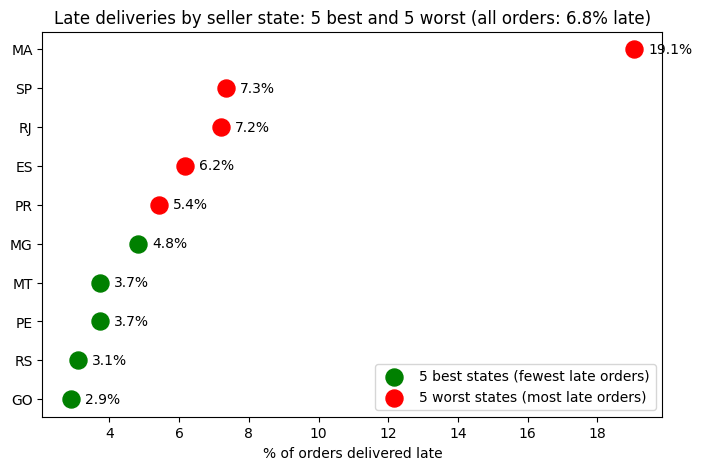

In [207]:
plt.figure(figsize=(8, 5))
plt.scatter(best5['percntage_late_days'], best5.index, s=150, color='green', label='5 best states (fewest late orders)')
plt.scatter(worst5['percntage_late_days'], worst5.index, s=150, color='red', label='5 worst states (most late orders)')
# write the % next to each dot
for state in best5.index:
    plt.text(best5.loc[state, 'percntage_late_days'] + 0.4, state, f"{best5.loc[state, 'percntage_late_days']:.1f}%", va='center')
for state in worst5.index:
    plt.text(worst5.loc[state, 'percntage_late_days'] + 0.4, state, f"{worst5.loc[state, 'percntage_late_days']:.1f}%", va='center')
plt.title(f'Late deliveries by seller state: 5 best and 5 worst (all orders: {national_late:.1f}% late)')
plt.xlabel('% of orders delivered late')
plt.legend()
plt.show()

##### 5. Does seller-customer distance correlate with higher freight or longer delivery times?

In [68]:
# to calculate the distance Iwill use this library 
!pip install geopy


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip




   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---

In [65]:
from geopy.distance import geodesic

In [66]:
full_geo_df.columns

Index(['order_id', 'order_item_id', 'seller_id', 'price', 'freight_value',
       'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'customer_state_name', 'delivery_days', 'carrier_delivery_days',
       'delay_days', 'is_late', 'seller_city', 'seller_state',
       'seller_state_name', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng', 'delivery_type'],
      dtype='object')

In [67]:
full_geo_df[['seller_lat', 'seller_lng', 'customer_lat', 'customer_lng']].isna().sum()

seller_lat      253
seller_lng      253
customer_lat    562
customer_lng    562
dtype: int64

- scince we have some null values and it is causing an issue for us, we'll drop them in a new dataframe

In [68]:
distance_df = full_geo_df.dropna(subset=['seller_lat','seller_lng','customer_lat','customer_lng']).copy()

In [69]:
distance_df = distance_df[['order_id', 'seller_id', 'customer_id', 'freight_value', 'delivery_days', 'seller_lat','seller_lng','customer_lat','customer_lng']].copy()

In [70]:
distance_df['distance_km'] = distance_df.apply(
    lambda row: geodesic(
        (row['seller_lat'], row['seller_lng']),
        (row['customer_lat'], row['customer_lng'])
    ).km,
    axis =1
)

In [71]:
my_corr = distance_df[['distance_km', 'freight_value', 'delivery_days']].corr()
my_corr

,distance_km,freight_value,delivery_days
distance_km,1.000000,0.389420,0.394373
freight_value,0.389420,1.000000,0.214832
delivery_days,0.394373,0.214832,1.000000


In [72]:
sample_df = distance_df.sample(1500, random_state=1)

In [73]:
corr_freight = distance_df['distance_km'].corr(distance_df['freight_value'])
corr_days = distance_df['distance_km'].corr(distance_df['delivery_days'])

In [74]:
freight_max = distance_df['freight_value'].quantile(0.99)
days_max = distance_df['delivery_days'].quantile(0.99)

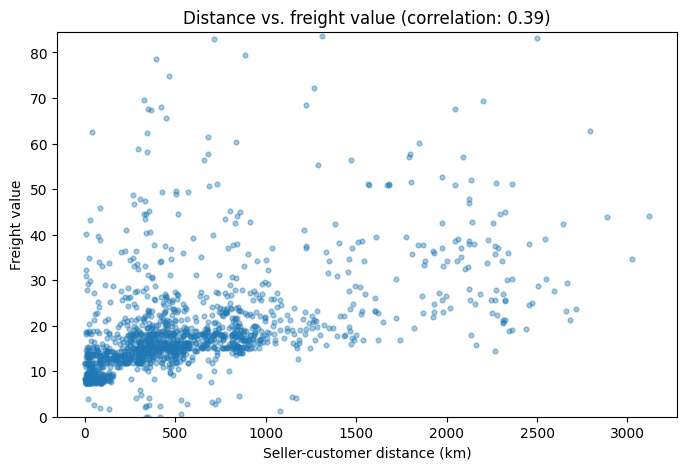

In [75]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df['distance_km'], sample_df['freight_value'], alpha=0.4, s=12)
plt.ylim(0, freight_max)
plt.title(f'Distance vs. freight value (correlation: {corr_freight:.2f})')
plt.xlabel('Seller-customer distance (km)')
plt.ylabel('Freight value')
plt.show()

In [78]:
distance_df['distance_group'] = 'Under 300 km'
distance_df.loc[distance_df['distance_km'] >= 300, 'distance_group'] = '300 - 1000 km'
distance_df.loc[distance_df['distance_km'] >= 1000, 'distance_group'] = 'Over 1000 km'
days_df = distance_df.dropna(subset=['delivery_days'])
distance_df['distance_group'].value_counts()

distance_group
300 - 1000 km    57625
Under 300 km     36581
Over 1000 km     17626
Name: count, dtype: int64

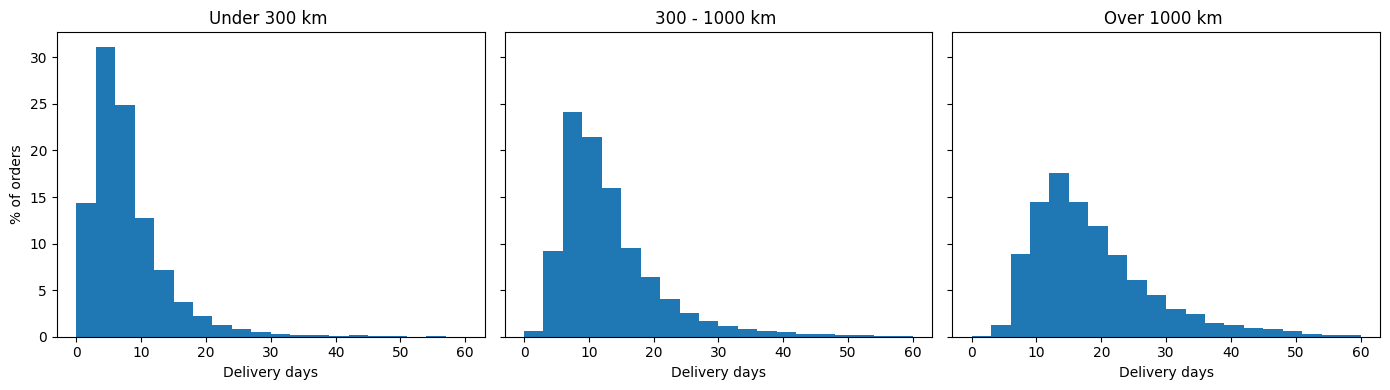

In [169]:
groups = ['Under 300 km', '300 - 1000 km', 'Over 1000 km']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for i in range(3):
    group_days = days_df[days_df['distance_group'] == groups[i]]['delivery_days']
    axes[i].hist(group_days, bins=range(0, 61, 3), weights=[100 / len(group_days)] * len(group_days))
    axes[i].set_title(f'{groups[i]} ')
    axes[i].set_xlabel('Delivery days')
axes[0].set_ylabel('% of orders')
plt.tight_layout()
plt.show()

### Part 5:

#### 1. Creating the tables that will be needed:

**Table One**

In [80]:
reviews_df = pd.read_csv('../Data_Cleaning/olist_order_reviews_dataset_cleaned.csv')

- The datasets has no clear `reason` column, so we will use the customers comment texts to get any clue about the issues

In [81]:
reviews_df['review_text'] = reviews_df['review_comment_title_english'].fillna('') + ' ' + reviews_df['review_comment_message_english'].fillna('')

In [82]:
#we turn it to lower cases so then when we search we get the triggered words
reviews_df['review_text'] = reviews_df['review_text'].str.lower()

In [83]:
#now we create our flagging columns:
reviews_df['damage_mention'] = reviews_df['review_text'].str.contains('damage|broken|defect|crack|torn', na=False)
reviews_df['delay_mention'] = reviews_df['review_text'].str.contains("late|delay|never arrived|not arrived|haven't arrived|hasn't arrived|not delivered | didn't receive | never received ", na=False)

In [84]:
#lastly we merge the reviews table we enhanced with the table we created in part 4, orders_customers_df
orders_reviews_df = pd.merge(orders_customers_df, reviews_df, left_on='order_id', right_on='order_id', how = 'left')

**Table Two**

some orders have more than one item so each will be in a seoerate row, to chnage that we are grouping so each order id will get just one row:

In [85]:
review_summary = reviews_df.groupby('order_id', as_index=False).agg({'review_score': 'min', 'damage_mention': 'max', 'delay_mention': 'max'})

In [86]:
#now we'll merge the full_info table (we need these informations for Q4 and Q5) with the review_summary
items_reviews_df = pd.merge(full_info_df, review_summary, left_on='order_id', right_on='order_id', how='left')

In [87]:
products_df = pd.read_csv('../Data_Cleaning/olist_products_dataset_cleaned.csv')

In [88]:
# we need the product category for Q5
products_df_part = products_df[['product_id', 'product_category_name']]

In [89]:
reviews_table02 = pd.merge(items_reviews_df, products_df_part, left_on='product_id', right_on='product_id', how='left')

In [90]:
#to get the english translation
cat_name = pd.read_csv('../Data_Cleaning/product_category_name_translation.csv')

In [91]:
reviews_table02['product_category_name'].isin(cat_name['product_category_name_english']).sum()

np.int64(7633)

In [92]:
len(reviews_table02) 

112646

- as it is shown above there is a diffrance in numbers, because not all product categories have their name translated. therefore we'll be using `products` table alongside the `category translated` table 

In [93]:
reviews_table02 = pd.merge(reviews_table02, cat_name, left_on='product_category_name', right_on='product_category_name', how='left')

In [94]:
#this is how we'll solve the issue
reviews_table02['product_category_name_english'] = reviews_table02['product_category_name_english'].fillna(reviews_table02['product_category_name'])

In [95]:
reviews_table02['product_category_name_english'].isnull().sum()

np.int64(0)

 Now we want to keep only the delivered orders: 

In [97]:
delivered_items = reviews_table02[reviews_table02['order_status'] == 'delivered'].copy()

In [98]:
delivered_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name', 'review_score', 'damage_mention', 'delay_mention',
       'product_category_name', 'product_category_name_english'],
      dtype='object')

In [99]:
delivered_items['delay_mention'].dtype

dtype('O')

In [102]:
# to make the data type boolean
delivered_items['damage_mention'] = delivered_items['damage_mention'] == True
delivered_items['delay_mention'] = delivered_items['delay_mention'] == True

In [103]:
delivered_items['damage_mention'].dtype

dtype('bool')

- Now this is very important as we'll split the **seller's part** and the **carrier's part**

In [104]:
delivered_items['shipping_limit_date'].dtypes

dtype('O')

In [105]:
delivered_items['shipping_limit_date'] = pd.to_datetime(delivered_items['shipping_limit_date'])

In [106]:
#to find how much did the order stay with the seller 
delivered_items['seller_handling_days'] = (delivered_items['order_delivered_carrier_date'] - delivered_items['order_purchase_timestamp']).dt.days

In [107]:
#this will show true if the seller was late in handing the order
delivered_items['seller_late_handoff'] = delivered_items['order_delivered_carrier_date'] > delivered_items['shipping_limit_date']

In [108]:
# a column to track all orders with any delivery issue
delivered_items['delivery_issue'] = delivered_items['is_late'] | delivered_items['delay_mention'] | delivered_items['damage_mention']

- To have one row per order and seller. As an order with several items would otherwise be counted several times: 

In [109]:
delivered_items.duplicated(['seller_id', 'order_id']).sum()

np.int64(12357)

In [110]:
seller_orders = delivered_items.groupby(['seller_id', 'order_id']).agg(
    seller_state = ('seller_state', 'first'),
    is_late = ('is_late', 'first'),
    seller_late_handoff = ('seller_late_handoff', 'max'),
    seller_handling_days = ('seller_handling_days', 'first'),
    carrier_delivery_days = ('carrier_delivery_days', 'first'),
    damage_mention = ('damage_mention', 'max'),
    delivery_issue = ('delivery_issue', 'max')
).reset_index()

In [111]:
seller_orders.duplicated(['seller_id', 'order_id']).sum()

np.int64(0)

#### 2. Answering the Questions:

##### 1. How does delivery performance affect customer satisfaction and reviews?

- we want to have the orders that got delivered and also have a review scorw the asses the performance: 

In [112]:
needed_cols = ['order_id', 'review_score', 'delivery_days', 'delay_days', 'is_late']
delivered_score = orders_reviews_df[ (orders_reviews_df['order_status'] == 'delivered')& (orders_reviews_df['review_score'].notnull())][needed_cols].copy()

In [113]:
#check how the satisfactions differs between late and not late orders
delivered_score.groupby('is_late')[['review_score']].mean()

,review_score
is_late,
False,4.290200
True,2.270528


In [114]:
#classifying how late an order is
delivered_score['delay_explanation'] = 'Early more than a week'
delivered_score.loc[delivered_score['delay_days'] > -8, 'delay_explanation'] = 'Early 0-7 days'
delivered_score.loc[delivered_score['delay_days'] > 0, 'delay_explanation'] = 'Late 1-3 days'
delivered_score.loc[delivered_score['delay_days'] > 3, 'delay_explanation'] = 'Late 4-7 days'
delivered_score.loc[delivered_score['delay_days'] > 7, 'delay_explanation'] = 'Late more than a week'

In [115]:
#classify what is a low score for us
delivered_score['low_score'] = delivered_score['review_score'] <=2

In [116]:
delay_summary = delivered_score.groupby('delay_explanation').agg(
    avg_review_score = ('review_score', 'mean'),
    low_score_pct = ('low_score', 'mean'), 
    reviews_count = ('review_score', 'count') )
delay_summary['low_score_pct'] *= 100

In [117]:
#checking the table insights 
delay_summary

,avg_review_score,low_score_pct,reviews_count
delay_explanation,,,
Early 0-7 days,4.188301,10.413303,18582
Early more than a week,4.316808,8.975170,71163
Late 1-3 days,3.289488,32.183288,1855
Late 4-7 days,2.103193,67.673888,1754
Late more than a week,1.699678,79.191991,2797


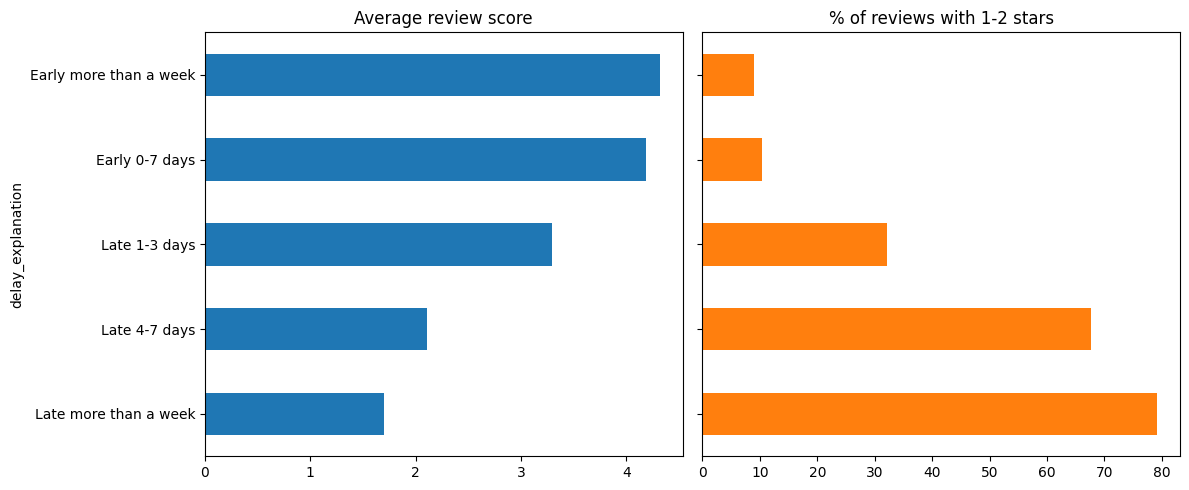

In [118]:
y_order = ['Late more than a week', 'Late 4-7 days', 'Late 1-3 days', 'Early 0-7 days', 'Early more than a week']
delay_plot_df = delay_summary.loc[y_order, ['avg_review_score', 'low_score_pct']]
delay_plot_df.plot(kind='barh', subplots=True, layout=(1, 2), figsize=(12, 5) ,legend=False, sharex=False, sharey=True, title=['Average review score', '% of reviews with 1-2 stars'])
plt.tight_layout()

plt.show()

In [119]:
delivered_score[['delivery_days', 'delay_days', 'review_score']].corr()

,delivery_days,delay_days,review_score
delivery_days,1.000000,0.602374,-0.334118
delay_days,0.602374,1.000000,-0.267810
review_score,-0.334118,-0.267810,1.000000


##### 2. What percentage of order cancellations are due to shipping problems?

In [120]:
# we need to first get the canceled orders 
canceled = orders_reviews_df[orders_reviews_df['order_status'] == 'canceled'].copy()

In [121]:
canceled['damage_mention'].dtype

dtype('O')

In [122]:
# orders without a review have empty flags so they become False
canceled['damage_mention'] = canceled['damage_mention'] == True
canceled['delay_mention'] = canceled['delay_mention'] == True

In [123]:
canceled['damage_mention'].dtype

dtype('bool')

In [124]:
# we want to make sure that each order is counted once only 
canceled_orders = canceled.groupby('order_id'). agg({'order_delivered_carrier_date': 'first', 'delay_mention': 'max', 'damage_mention': 'max'})

In [125]:
#now we'll make our criterias 
canceled_orders['carrier_received'] = canceled_orders['order_delivered_carrier_date'].notnull()
canceled_orders['complaint'] = canceled_orders['delay_mention'] | canceled_orders['damage_mention']
canceled_orders['shipping_issues'] = canceled_orders['carrier_received'] & canceled_orders['complaint']

In [126]:
canceled_pct = canceled_orders[['carrier_received', 'complaint' , 'shipping_issues']].mean() * 100
canceled_pct

carrier_received    12.00
complaint           12.80
shipping_issues      1.28
dtype: float64

- Only about 12% of canceled orders had reached the carrier so most cancellations happened before shipping

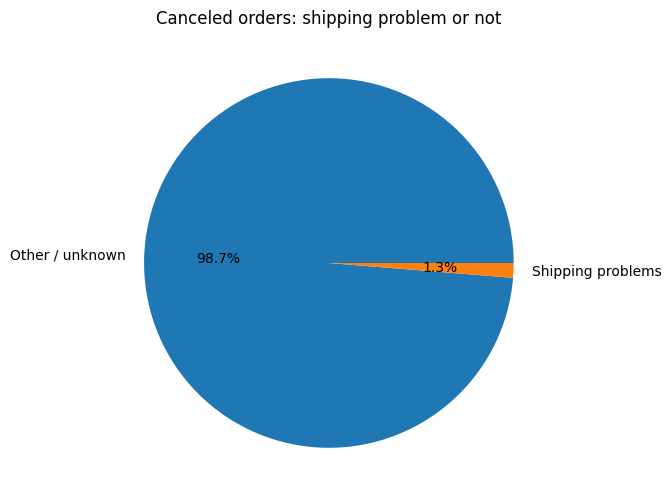

In [181]:
canceled_orders['shipping_issues'].map({True: 'Shipping problems', False: 'Other / unknown'}).value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Canceled orders: shipping problem or not')
plt.ylabel('')
plt.show()

##### 3. How many cancellations or complaints relate to late or damaged deliveries?

**Part 1: complaints relate to late or damaged deliveries:**

In [128]:
#for the coplaints we only have the comments to rely on so we'll get the orders that have a review:
reviews_df['has_comment'] = reviews_df['review_text'].str.strip() != ''
reviews_df['has_comment'].sum()

np.int64(42686)

In [129]:
#then we neet to classify each review  
reviews_df['reviews_type'] = 'No delay/ damage mentioned'
reviews_df.loc[reviews_df['delay_mention'], 'reviews_type'] = 'Delay only'
reviews_df.loc[reviews_df['damage_mention'], 'reviews_type'] = 'Damaged only'
reviews_df.loc[reviews_df['damage_mention'] & reviews_df['delay_mention'], 'reviews_type'] = 'Both late and damaged'

In [130]:
complaint_reviews_count = reviews_df['reviews_type'].value_counts()
complaint_reviews_count

reviews_type
No delay/ damage mentioned    95666
Delay only                     2501
Damaged only                   1021
Both late and damaged            36
Name: count, dtype: int64

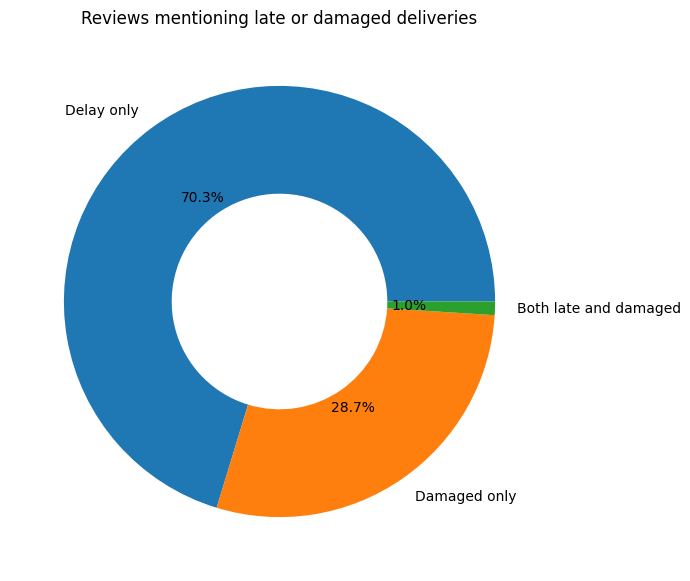

In [179]:
#we just want to check the onees with delay or damages mentioned
complaint_only = complaint_reviews_count.drop('No delay/ damage mentioned')
comments_total = reviews_df['has_comment'].sum()
complaint_only.plot(kind='pie', autopct='%1.1f%%' , figsize=(7, 7), wedgeprops={'width': 0.5}, title='Reviews mentioning late or damaged deliveries')
plt.ylabel('')
plt.show()

**Part 2: cancelation relate to late or damaged deliveries:**

In [132]:
# I'll use the canceled from question 2
canceled_orders['cancel_type'] = 'No delay/ damage mentioned'
canceled_orders.loc[canceled_orders['delay_mention'], 'cancel_type'] = 'Delay only'
canceled_orders.loc[canceled_orders['damage_mention'], 'cancel_type'] = 'Damaged only'
canceled_orders.loc[canceled_orders['delay_mention'] & canceled_orders['damage_mention'], 'cancel_type'] = 'Both late and damaged'

In [133]:
cancel_type_counts = canceled_orders['cancel_type'].value_counts()
cancel_type_counts

cancel_type
No delay/ damage mentioned    545
Delay only                     64
Damaged only                   15
Both late and damaged           1
Name: count, dtype: int64

In [134]:
cancel_only = cancel_type_counts.drop('No delay/ damage mentioned')
canceled_total = len(canceled_orders)

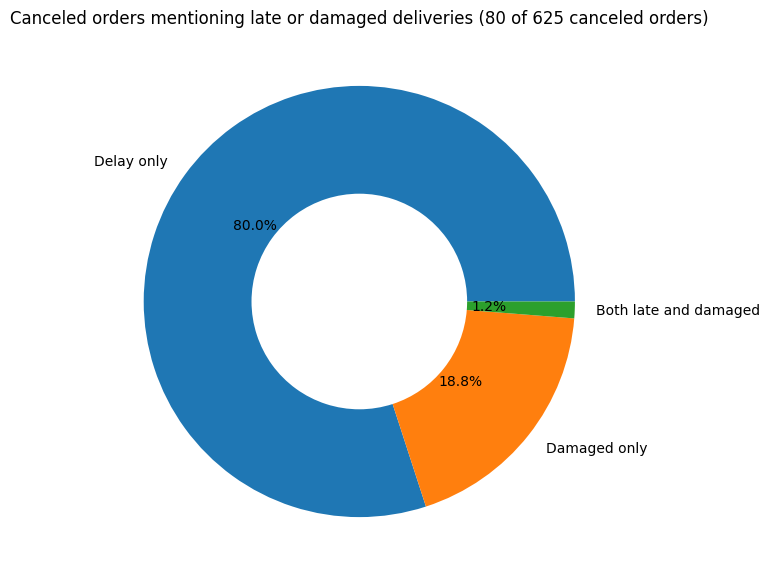

In [135]:
cancel_only.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7), wedgeprops={'width': 0.5}, title=f'Canceled orders mentioning late or damaged deliveries ({cancel_only.sum()} of {canceled_total} canceled orders)')
plt.ylabel('')
plt.show()

##### 4. Are there specific sellers with repeated delivery issues (suggesting seller-related problems)?

In [136]:
# we want to check per seller
seller_summary = seller_orders.groupby('seller_id').agg(
    seller_state = ('seller_state', 'first'),
    orders = ('order_id', 'count'),
    issue_orders = ('delivery_issue', 'sum'),
    issue_pct = ('delivery_issue', 'mean')
)
seller_summary['issue_pct'] *= 100

In [137]:
seller_summary.head(2)

,seller_state,orders,issue_orders,issue_pct
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,SP,3,0,0.000000
001cca7ae9ae17fb1caed9dfb1094831,ES,195,26,13.333333


In [138]:
# we will filter out any seller with less than 30 orders
seller_filtered = seller_summary[seller_summary['orders'] >= 30]
overall_issue_pct = seller_orders['delivery_issue'].mean() * 100

In [139]:
top_sellers = seller_filtered.sort_values('issue_pct', ascending=False).head(10) #to top 10 sellers with issues
top_sellers

,seller_state,orders,issue_orders,issue_pct
seller_id,,,,
ad781527c93d00d89a11eecd9dcad7c1,SP,38,14,36.842105
2a1348e9addc1af5aaa619b1a3679d6b,MG,48,16,33.333333
54965bbe3e4f07ae045b90b0b8541f52,PR,73,24,32.876712
ede0c03645598cdfc63ca8237acbe73d,SP,43,14,32.558140
835f0f7810c76831d6c7d24c7a646d4d,SP,42,12,28.571429
beadbee30901a7f61d031b6b686095ad,SP,64,16,25.000000
712e6ed8aa4aa1fa65dab41fed5737e4,SC,77,19,24.675325
a49928bcdf77c55c6d6e05e09a9b4ca5,SP,96,23,23.958333
ec8879960bd2221d5c32f8e12f7da711,SP,35,8,22.857143


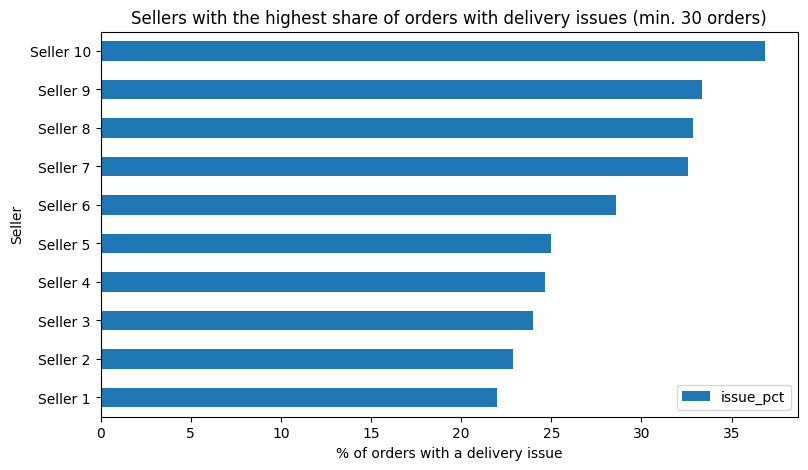

In [176]:
top_sellers = top_sellers.sort_values('issue_pct', ascending=True)
top_sellers['seller_label'] = [
    f'Seller {i}' for i in range(1, len(top_sellers) + 1)
]

top_sellers.plot( x='seller_label', y='issue_pct', kind='barh', figsize=(9, 5))

plt.title('Sellers with the highest share of orders with delivery issues (min. 30 orders)')
plt.xlabel('% of orders with a delivery issue')
plt.ylabel('Seller')
plt.show()

In [172]:
top_sellers

,seller_state,orders,issue_orders,issue_pct,seller_label
seller_id,,,,,
ad781527c93d00d89a11eecd9dcad7c1,SP,38,14,36.842105,Seller 1
2a1348e9addc1af5aaa619b1a3679d6b,MG,48,16,33.333333,Seller 2
54965bbe3e4f07ae045b90b0b8541f52,PR,73,24,32.876712,Seller 3
ede0c03645598cdfc63ca8237acbe73d,SP,43,14,32.558140,Seller 4
835f0f7810c76831d6c7d24c7a646d4d,SP,42,12,28.571429,Seller 5
beadbee30901a7f61d031b6b686095ad,SP,64,16,25.000000,Seller 6
712e6ed8aa4aa1fa65dab41fed5737e4,SC,77,19,24.675325,Seller 7
a49928bcdf77c55c6d6e05e09a9b4ca5,SP,96,23,23.958333,Seller 8
ec8879960bd2221d5c32f8e12f7da711,SP,35,8,22.857143,Seller 9


##### 5. Are broken or delayed items concentrated with certain sellers, products, or categories (shipping vs. seller responsibility)?

**Part 1: Who is responsible for delays?**

In [141]:
late_orders = seller_orders[seller_orders['is_late'] == True]

In [142]:
# average days at each stage to check for on-time vs. late orders
stage_time = seller_orders.groupby('is_late')[['seller_handling_days', 'carrier_delivery_days']].mean()
stage_time.index = ['On time', 'Late']
stage_time

,seller_handling_days,carrier_delivery_days
On time,2.523980,7.518455
Late,5.587408,27.380654


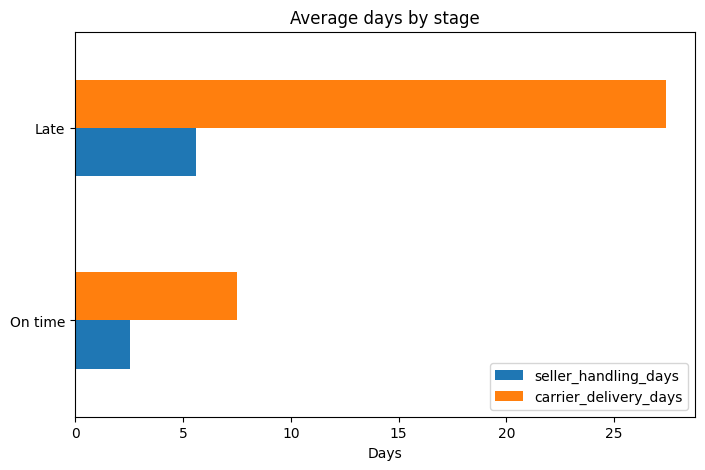

In [177]:
stage_time.plot(kind='barh', figsize=(8, 5), title='Average days by stage')
plt.xlabel('Days')
plt.show()

**Part 2: is certin category always damaged?**

In [144]:
category_orders = delivered_items.drop_duplicates(subset=['order_id', 'product_category_name_english'])

In [145]:
category_summary = category_orders.groupby('product_category_name_english').agg(
    orders = ('order_id', 'count'),
    issue_pct = ('delivery_issue', 'mean'),
    damage_pct = ('damage_mention', 'mean'),
    late_pct = ('is_late', 'mean')
)
category_summary[['issue_pct', 'damage_pct', 'late_pct']] *= 100
category_summary

,orders,issue_pct,damage_pct,late_pct
product_category_name_english,,,,
agro_industry_and_commerce,177,6.214689,2.259887,3.954802
air_conditioning,246,8.130081,3.252033,4.065041
art,195,8.205128,0.000000,6.153846
arts_and_craftmanship,23,17.391304,8.695652,4.347826
audio,348,14.942529,2.873563,11.781609
...,...,...,...,...
tablets_printing_image,79,6.329114,0.000000,5.063291
telephony,4087,10.178615,2.006362,7.120137
toys,3795,8.379447,1.054018,6.403162


In [146]:
#to analyze it better we'll only take categories with more than 100 order
category_filtered = category_summary[category_summary['orders'] >= 100].sort_values('issue_pct', ascending=False)
category_top = category_filtered.head(10)
category_top

,orders,issue_pct,damage_pct,late_pct
product_category_name_english,,,,
audio,348,14.942529,2.873563,11.781609
office_furniture,1253,13.727055,3.910615,8.060654
home_confort,389,10.796915,0.514139,9.511568
food,439,10.478360,1.594533,7.061503
industry_commerce_and_business,230,10.434783,2.173913,6.956522
electronics,2512,10.390127,1.393312,7.643312
baby,2805,10.374332,0.891266,8.057041
kitchen_dining_laundry_garden_furniture,241,10.373444,2.489627,4.564315
fashion_underwear_beach,117,10.256410,0.000000,9.401709


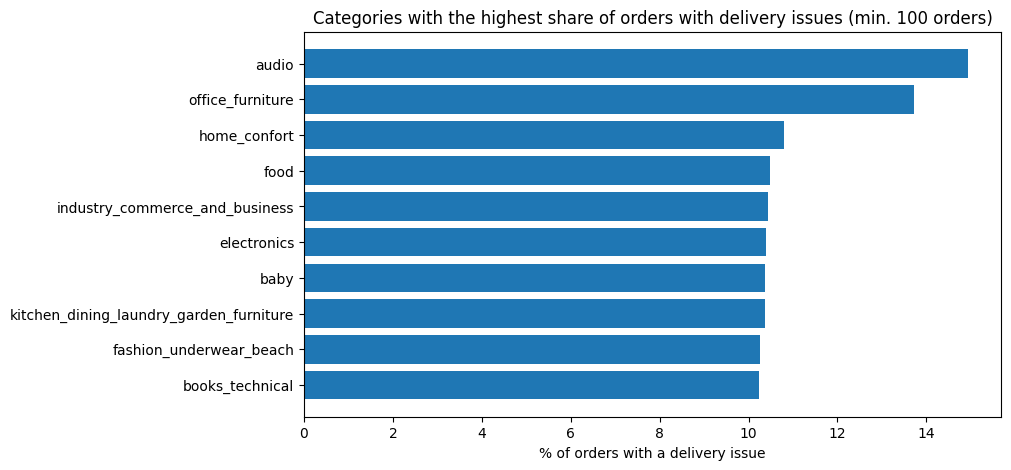

In [157]:
plt.figure(figsize=(9, 5))
plt.barh(category_top.index, category_top['issue_pct'])
plt.gca().invert_yaxis()
plt.title('Categories with the highest share of orders with delivery issues (min. 100 orders)')
plt.xlabel('% of orders with a delivery issue')
plt.show()

**Part 3: does specific product cause issues**

In [148]:
product_orders = delivered_items.drop_duplicates(subset=['order_id', 'product_id'])

In [149]:
product_summary = product_orders.groupby('product_id').agg(orders=('order_id', 'count'), issue_pct=('delivery_issue', 'mean'), damage_pct=('damage_mention', 'mean'))
product_summary[['issue_pct', 'damage_pct']] *= 100
product_summary

,orders,issue_pct,damage_pct
product_id,,,
00066f42aeeb9f3007548bb9d3f33c38,1,0.0,0.0
00088930e925c41fd95ebfe695fd2655,1,0.0,0.0
0009406fd7479715e4bef61dd91f2462,1,0.0,0.0
000b8f95fcb9e0096488278317764d19,2,0.0,0.0
000d9be29b5207b54e86aa1b1ac54872,1,0.0,0.0
...,...,...,...
fff6177642830a9a94a0f2cba5e476d1,2,0.0,0.0
fff81cc3158d2725c0655ab9ba0f712c,1,0.0,0.0
fff9553ac224cec9d15d49f5a263411f,1,0.0,0.0


- there are a lot of products with only one order so to avoid them: 

In [150]:
product_summary[product_summary['orders'] >= 30].sort_values('issue_pct', ascending=False).head(10)

,orders,issue_pct,damage_pct
product_id,,,
1dec4c88c685d5a07bf01dcb0f8bf9f8,35,42.857143,0.000000
9ad75bd7267e5c724cb42c71ac56ca72,39,38.461538,0.000000
83b00325c13c44245b2c3a2befa62a0e,33,33.333333,3.030303
89b121bee266dcd25688a1ba72eefb61,57,29.824561,15.789474
0cf41187284d7f099adc8415a743ebbd,32,28.125000,3.125000
4cc8bfa581f41841ce5e24aba773a44a,32,28.125000,0.000000
3fbc0ef745950c7932d5f2a446189725,143,27.272727,0.000000
2fea0f2cec6b6324a277d4a61c2ed2c6,55,25.454545,0.000000
7b85e3deef35afd6ebed5461ee8f0641,32,25.000000,0.000000
